# Phase 1: Bayesian DoE Optimisation
reads Team Alpha + Beta CSVs, fully data-driven

Issues fixed: hardcoded API/excipients, untrained GP, fake EHVI, physics-free simulator, 
mass-balance constraint, CPP interactions, LOO-CV R², uncertainty export, 
API-specific bounds, BO feasibility filter, sensitivity indices, EHVI-decay convergence.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import json, os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from copy import deepcopy
from datetime import datetime
from pathlib import Path
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.utils.multi_objective.pareto import is_non_dominated
from botorch.acquisition.multi_objective.logei import qLogNoisyExpectedHypervolumeImprovement
from botorch.utils.sampling import draw_sobol_samples
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
print('✓ imports OK')

✓ imports OK


In [2]:
print('=' * 70)
print('STEP 0 — DATA LOADING')
print('=' * 70)

ROOT = Path.cwd().parent
DATA = ROOT / 'data'

alpha_df = pd.read_csv(DATA / 'team_alpha_dummy.csv')
beta_df  = pd.read_csv(DATA / 'team_beta_dummy.csv')

# ── parse JSON columns that are stored as strings ────────────────────────
# Both CSVs have columns like concentration_range_pct, process_parameters,
# shap_values_per_excipient stored as JSON strings. Parse them once here.
for df, cols in [
    (alpha_df, ['concentration_range_pct', 'process_parameters',
                'shap_values_per_excipient', 'alternatives_for_role',
                'rejected_excipients', 'alternative_techniques']),
    (beta_df,  ['concentration_range_pct', 'process_parameters',
                'shap_values_per_excipient', 'alternatives_for_role',
                'rejected_excipients', 'alternative_techniques']),
]:
    for col in cols:
        if col in df.columns:
            df[col] = df[col].apply(
                lambda x: json.loads(x) if isinstance(x, str) and x.strip().startswith(('{','[')) else x
            )

print(f'Alpha: {alpha_df.shape[0]} rows × {alpha_df.shape[1]} cols')
print(f'Beta : {beta_df.shape[0]} rows × {beta_df.shape[1]} cols')
print(f'Unique APIs — Alpha: {alpha_df.api_name.nunique()}  Beta: {beta_df.api_name.nunique()}')

STEP 0 — DATA LOADING
Alpha: 1000 rows × 41 cols
Beta : 400 rows × 38 cols
Unique APIs — Alpha: 46  Beta: 45


In [3]:
print('\n' + '=' * 70)
print('STEP 0b — MERGE ON api_name')
print('=' * 70)

# Inner join on api_name — only APIs present in BOTH datasets proceed.
# suffixes: _a = Team Alpha column, _b = Team Beta column when names clash.
merged = pd.merge(alpha_df, beta_df, on='api_name', how='inner', suffixes=('_a', '_b'))
print(f'Merged: {len(merged)} rows, {len(merged.columns)} cols')
print(f'APIs available: {merged.api_name.unique().tolist()}')

# ── helper: pick a row for a given API name ──────────────────────────────
def get_row(api_name: str) -> pd.Series:
    """
    FIX #1 — was iloc[55] / iloc[0]. Now selects by API name.
    If the same API has multiple excipient rows (one row per excipient),
    we take the first — the full excipient list is built in build_beta().
    """
    rows = merged[merged.api_name == api_name]
    if rows.empty:
        raise ValueError(f'API "{api_name}" not found. Available: {merged.api_name.unique().tolist()}')
    return rows.iloc[0]  # representative row; all rows for this API used in build_beta()

# ── choose which API to run — change this one line to switch APIs ─────────
TARGET_API = merged.api_name.iloc[0]   # default: first available; override as needed
print(f'\nTarget API: {TARGET_API}')


STEP 0b — MERGE ON api_name
Merged: 8113 rows, 78 cols
APIs available: ['Paracetamol', 'Simvastatin', 'Celecoxib', 'Verapamil', 'Fenofibrate', 'Piroxicam', 'Ketoprofen', 'Chlorothiazide', 'Repaglinide', 'Glibenclamide', 'Hydrochlorothiazide', 'Naproxen', 'Progesterone', 'Metformin', 'Ranitidine', 'Tamoxifen', 'Lopinavir', 'Cimetidine', 'Metoprolol', 'Ezetimibe', 'Mefenamic acid', 'Indomethacin', 'Theophylline', 'Fluconazole', 'Griseofulvin', 'Spironolactone', 'Captopril', 'Ibuprofen', 'Ritonavir', 'Ketoconazole', 'Atorvastatin', 'Amoxicillin', 'Dexamethasone', 'Clotrimazole', 'Nifedipine', 'Acyclovir', 'Atenolol', 'Danazol', 'Prednisolone', 'Furosemide', 'Warfarin', 'Caffeine', 'Carbamazepine']

Target API: Paracetamol


In [4]:
print('\n' + '=' * 70)
print('STEP 1a — BUILD TEAM ALPHA & BETA FROM REAL DATA')
print('=' * 70)

def build_alpha(row: pd.Series) -> dict:
    """
    Reads every required Team Alpha field directly from the dataset row.
    No hardcoded values — if a field is missing it raises immediately.
    Column mapping mirrors the actual CSV column names.
    """
    def _float(key, fallback=None):
        v = row.get(key, fallback)
        return float(v) if pd.notna(v) and v != '' else fallback

    return {
        'api_name'              : str(row['api_name']),
        'smiles'                : str(row.get('smiles', '')),
        'molecular_weight'      : _float('molecular_weight', _float('molecular_weight_da', 300)),
        'logP'                  : _float('logP', 2.0),
        'bcs_class'             : str(row.get('bcs_class_a', row.get('bcs_class', 'II'))),
        'decomposition_onset_c' : _float('decomposition_onset_c', _float('melting_point_c', 200)),
        'hygroscopicity_class'  : str(row.get('hygroscopicity_class', 'low')).lower(),
        'polymorphism_risk_tier': str(row.get('polymorphism_risk_tier', 'low')).lower(),
        'particle_size_d50_um'  : _float('particle_size_d50_um', 50),
        'bulk_density_g_ml'     : _float('bulk_density_g_ml', 0.45),
        'flow_properties_carr_index': _float('flow_properties_carr_index', 25),
        'dose_mg'               : _float('dose_mg_a', _float('dose_mg', 100)),
    }


def build_beta(api_name: str) -> dict:
    """
    FIX #2 — was hardcoded Croscarmellose + Mg Stearate.
    Reads ALL excipient rows for this API from the merged dataset.
    Each row in the merged CSV represents one API-excipient combination,
    so we group by api_name and collect every excipient the teams recommended.

    Why one row per excipient?
    Team Beta's compatibility engine scores each excipient independently
    and returns one record per candidate. The merge creates multiple rows
    per API — one for every (API, excipient) pair that passed screening.
    """
    api_rows = merged[merged.api_name == api_name]

    excipients = []
    for _, r in api_rows.iterrows():
        # concentration_range_pct is already parsed to dict above
        conc = r.get('concentration_range_pct_a', r.get('concentration_range_pct', {}))
        if isinstance(conc, str):
            try: conc = json.loads(conc)
            except: conc = {'min': 5, 'max': 50}
        if not isinstance(conc, dict):
            conc = {'min': 5, 'max': 50}

        excipients.append({
            'name'                  : str(r.get('excipient_name', r.get('primary_excipient', 'MCC'))),
            'functional_role'       : str(r.get('functional_role_a', r.get('excipient_role', 'filler'))),
            'compatibility_tier'    : int(r.get('compatibility_tier', 2)),
            'compatibility_score'   : float(r.get('composite_compatibility', r.get('compatibility_score', 0.7))),
            'moisture_stability'    : float(r.get('moisture_stability_a', r.get('moisture_stability', 0.8))),
            'polymorphic_risk'      : float(r.get('polymorphic_risk_a', r.get('polymorphic_risk', 0.1))),
            'concentration_range_pct': conc,
            'shap_values'           : r.get('shap_values_per_excipient_a',
                                            r.get('shap_values_per_excipient', [])),
            'desirability_weight'   : float(r.get('desirability_weight_a', r.get('desirability_weight', 0.5))),
        })

    # ── CQA specs: read from process_parameters of first row ─────────────
    first = api_rows.iloc[0]
    # Derive CQA targets from BCS class — BCS I dissolves easily, BCS II needs >80%
    bcs = str(first.get('bcs_class_a', first.get('bcs_class', 'II')))
    diss_target = 85 if bcs in ('I', 'III') else 80

    return {
        'excipients': excipients,
        'primary_technique': str(first.get('primary_technique_a', first.get('primary_technique', 'wet_granulation'))),
        'technique_confidence': float(first.get('technique_confidence_a', first.get('technique_confidence', 0.7))),
        'cqa_specifications': {
            'hardness_N'           : [80, 120],
            'dissolution_30min_pct': diss_target,
            'friability_pct'       : 1.0,
            'uniformity_rsd_pct'   : 6.0,
        },
    }


row   = get_row(TARGET_API)
alpha = build_alpha(row)
beta  = build_beta(TARGET_API)

print(f"\nAPI              : {alpha['api_name']}")
print(f"MW               : {alpha['molecular_weight']} g/mol")
print(f"BCS class        : {alpha['bcs_class']}")
print(f"Decomp onset     : {alpha['decomposition_onset_c']} °C")
print(f"Hygroscopicity   : {alpha['hygroscopicity_class']}")
print(f"Polymorphism risk: {alpha['polymorphism_risk_tier']}")
print(f"Carr index       : {alpha['flow_properties_carr_index']}")
print(f"Dose             : {alpha['dose_mg']} mg")
print(f"\nExcipients from Team Beta ({len(beta['excipients'])}):'")
for e in beta['excipients']:
    r = e['concentration_range_pct']
    print(f"  {e['name']:30s}  role={e['functional_role']:15s}  "
          f"conc=[{r.get('min',0)}–{r.get('max',50)}%]  "
          f"compat={e['compatibility_score']:.2f}")


STEP 1a — BUILD TEAM ALPHA & BETA FROM REAL DATA

API              : Paracetamol
MW               : 151.13 g/mol
BCS class        : I
Decomp onset     : 247.7 °C
Hygroscopicity   : low
Polymorphism risk: low
Carr index       : 23.9
Dose             : 500.0 mg

Excipients from Team Beta (230):'
  Lactose monohydrate             role=plasticizer      conc=[30–51%]  compat=0.76
  Lactose monohydrate             role=plasticizer      conc=[30–51%]  compat=0.76
  Lactose monohydrate             role=filler           conc=[30–51%]  compat=0.76
  Lactose monohydrate             role=plasticizer      conc=[30–51%]  compat=0.76
  Lactose monohydrate             role=solubilizer      conc=[30–51%]  compat=0.76
  Lactose monohydrate             role=filler           conc=[30–51%]  compat=0.76
  Lactose monohydrate             role=disintegrant     conc=[30–51%]  compat=0.76
  Lactose monohydrate             role=filler           conc=[30–51%]  compat=0.76
  Lactose monohydrate             role=d

In [5]:
print('\n' + '=' * 70)
print('STEP 1b — CPP SPACE DEFINITION (API-specific bounds)')
print('=' * 70)

def build_cpp_space(alpha: dict, beta: dict) -> dict:
    """
    FIX #21 — bounds are now API-specific, derived from real dataset fields.

    Every bound has a scientific comment explaining which biological/chemical
    property drives it:

    hygroscopicity_class  → moisture ceiling  (wet APIs absorb granulation liquid → sticking)
    decomposition_onset_c → temp ceiling      (95°C safety buffer below API breakdown point)
    polymorphism_risk_tier→ force ceiling     (pressure can convert crystal form → dissolution change)
    flow_properties_carr_index → force floor  (poor flow → uneven die fill → need higher force)
    bcs_class             → dissolution target (BCS II drugs need more help dissolving)
    dose_mg               → excipient headroom (high dose → less space for excipients)
    """
    bounds = {}

    # ── excipient CPP bounds — fully from Team Beta data ────────────────
    # FIX #2: no hardcoded excipient names or concentrations
    tablet_weight_mg   = alpha['dose_mg'] / 0.35  # assume dose is ~35% of tablet weight
    dose_fraction      = alpha['dose_mg'] / tablet_weight_mg
    available_pct      = (1.0 - dose_fraction) * 100  # % available for all excipients

    excip_keys = []
    for exc in beta['excipients']:
        r   = exc['concentration_range_pct']
        lo  = float(r.get('min', 5))
        hi  = min(float(r.get('max', 50)), available_pct * 0.7)  # cap at 70% of available space
        hi  = max(hi, lo + 1)                                     # guarantee lo < hi
        key = exc['name'].replace(' ', '_').replace('-', '_') + '_pct'
        bounds[key] = (lo, hi)
        excip_keys.append(key)

    # ── granulation moisture — hygroscopicity-adjusted ───────────────────
    moisture_ceil = {'low': 7.0, 'medium': 6.0, 'high': 5.0}.get(
        alpha['hygroscopicity_class'], 6.0)
    bounds['Granulation_Moisture_pct'] = (3.0, moisture_ceil)

    # ── drying temperature — 95°C buffer below decomposition onset ───────
    temp_hi = min(float(alpha['decomposition_onset_c']) - 95.0, 100.0)
    temp_hi = max(temp_hi, 65.0)   # minimum sensible drying temp
    bounds['Drying_Temperature_C'] = (55.0, temp_hi)

    # ── compression force — polymorphism-risk-adjusted ceiling ───────────
    force_ceil = {'low': 25.0, 'medium': 20.0, 'high': 16.0}.get(
        alpha['polymorphism_risk_tier'], 20.0)
    # Poor flow (high Carr index) needs more force for adequate die fill
    carr = alpha['flow_properties_carr_index']
    force_floor = 8.0 + max(0, (carr - 25) * 0.3)  # add 0.3 kN per Carr unit above 25
    bounds['Compression_Force_kN'] = (force_floor, force_ceil)

    # ── scale-up parameters (new — FIX for negative values) ─────────────
    # These are hard physical bounds: batch mass and equipment rpm cannot be negative.
    # The GP operates in normalised [0,1] space so extrapolation outside these
    # bounds is blocked at candidate generation, not just post-hoc.
    bounds['Batch_Scale_kg']    = (1.0,   100.0)
    bounds['Impeller_Speed_rpm'] = (150.0, 500.0)
    bounds['Blade_Speed_rpm']   = (150.0, 500.0)
    bounds['Scale_Factor']      = (1.0,   20.0)

    cpp_names = list(bounds.keys())
    lowers    = np.array([bounds[k][0] for k in cpp_names])
    uppers    = np.array([bounds[k][1] for k in cpp_names])

    return {
        'bounds'    : bounds,
        'cpp_names' : cpp_names,
        'lowers'    : lowers,
        'uppers'    : uppers,
        'excip_keys': excip_keys,
        'n_cpps'    : len(cpp_names),
    }


def build_cqa_objectives(beta: dict) -> dict:
    cqa = beta['cqa_specifications']
    return {
        'Hardness_N'           : {'target': 100, 'min': cqa['hardness_N'][0],
                                   'max': cqa['hardness_N'][1], 'higher_is_better': True},
        'Dissolution_30min_pct': {'target': cqa['dissolution_30min_pct'], 'min': 60,
                                   'max': 100, 'higher_is_better': True},
        'Friability_pct'       : {'target': 0.3, 'min': 0, 'max': cqa['friability_pct'],
                                   'higher_is_better': False},
        'Uniformity_RSD_pct'   : {'target': 2.0, 'min': 0, 'max': cqa['uniformity_rsd_pct'],
                                   'higher_is_better': False},
    }


space    = build_cpp_space(alpha, beta)
cqa_obj  = build_cqa_objectives(beta)
cqa_names = list(cqa_obj.keys())

print(f"\nCPP space ({space['n_cpps']} parameters):")
for k, (lo, hi) in space['bounds'].items():
    print(f'  {k:35s}  [{lo:7.2f}, {hi:7.2f}]')
print(f'\nCQA objectives: {cqa_names}')


STEP 1b — CPP SPACE DEFINITION (API-specific bounds)

CPP space (17 parameters):
  Lactose_monohydrate_pct              [  30.00,   45.50]
  Starch_1500_pct                      [  30.00,   41.00]
  DCPA_pct                             [  30.00,   45.50]
  MCC_PH101_pct                        [  30.00,   45.50]
  PEG_6000_pct                         [   5.00,   25.00]
  TBC_pct                              [   5.00,   22.00]
  HPC_LF_pct                           [  30.00,   45.50]
  PEG_4000_pct                         [   5.00,   21.00]
  TEC_pct                              [   5.00,   18.00]
  Mannitol_pct                         [  30.00,   45.50]
  Granulation_Moisture_pct             [   3.00,    7.00]
  Drying_Temperature_C                 [  55.00,  100.00]
  Compression_Force_kN                 [   8.00,   25.00]
  Batch_Scale_kg                       [   1.00,  100.00]
  Impeller_Speed_rpm                   [ 150.00,  500.00]
  Blade_Speed_rpm                      [ 150.00,

In [6]:
print('\n' + '=' * 70)
print('STEP 2 — LATIN HYPERCUBE SEED EXPERIMENTS')
print('=' * 70)

def latin_hypercube(lowers, uppers, n: int, seed: int = SEED) -> np.ndarray:
    """
    Standard LHS: guarantees uniform marginal coverage in every dimension.
    Formula: x_i^(j) = (perm_i^(j) + U_i^(j)) / n   scaled to [lower, upper].
    FIX #15 — n_seeds is now dimension-adaptive: max(4, n_cpps // 2)
    """
    rng  = np.random.default_rng(seed)
    d    = len(lowers)
    cuts = (np.arange(n) + rng.uniform(size=(d, n))) / n  # (d, n) in [0,1)
    for i in range(d):
        cuts[i] = rng.permutation(cuts[i])                # break correlation across dims
    samples = lowers + cuts.T * (uppers - lowers)         # (n, d) in original units
    return np.clip(samples, lowers, uppers)


def enforce_mass_balance(X: np.ndarray, excip_keys: list,
                          cpp_names: list, lowers: np.ndarray,
                          dose_fraction: float) -> np.ndarray:
    """
    FIX #11 — mass balance: sum(excipient_pct) + dose_pct must not exceed 100%.

    Why this matters (biology → CS translation):
    A tablet is a fixed physical object — everything in it must sum to 100%.
    The API (active drug) takes up dose_fraction of that 100%. Whatever is
    left is shared among excipients. If the optimizer assigns 60% MCC + 40%
    HPMC + 30% drug = 130%, that tablet cannot physically exist.
    This function proportionally scales excipient concentrations down whenever
    they collectively exceed the available space (100% - dose_fraction).
    """
    X = X.copy()
    excip_idx = [cpp_names.index(k) for k in excip_keys if k in cpp_names]
    if not excip_idx:
        return X
    available = (1.0 - dose_fraction) * 100
    totals = X[:, excip_idx].sum(axis=1)
    over   = totals > available
    if over.any():
        # scale down all excipients proportionally for over-budget rows
        scale = available / totals[over]
        X[over][:, excip_idx] *= scale[:, None]
        X[over][:, excip_idx] = np.clip(
            X[over][:, excip_idx],
            lowers[excip_idx], None
        )
    return X


dose_fraction = alpha['dose_mg'] / (alpha['dose_mg'] / 0.35)  # same as in build_cpp_space

# FIX #15 — adaptive seed count
n_seeds = max(4, space['n_cpps'] // 2)

X_obs = latin_hypercube(space['lowers'], space['uppers'], n_seeds)
X_obs = enforce_mass_balance(X_obs, space['excip_keys'],
                              space['cpp_names'], space['lowers'], dose_fraction)

print(f'Seeds generated: {n_seeds}  (adaptive: max(4, n_cpps//2) = max(4, {space["n_cpps"]}//2))')
df_lhs = pd.DataFrame(X_obs, columns=space['cpp_names']).round(3)
print(df_lhs.to_string())

# ── verify mass balance ───────────────────────────────────────────────────
excip_idx = [space['cpp_names'].index(k) for k in space['excip_keys'] if k in space['cpp_names']]
totals    = X_obs[:, excip_idx].sum(axis=1) + dose_fraction * 100
print(f'\nMass balance check (excipients + API, should be ≤ 100%): {totals.round(1)}')


STEP 2 — LATIN HYPERCUBE SEED EXPERIMENTS
Seeds generated: 8  (adaptive: max(4, n_cpps//2) = max(4, 17//2))
   Lactose_monohydrate_pct  Starch_1500_pct  DCPA_pct  MCC_PH101_pct  PEG_6000_pct  TBC_pct  HPC_LF_pct  PEG_4000_pct  TEC_pct  Mannitol_pct  Granulation_Moisture_pct  Drying_Temperature_C  Compression_Force_kN  Batch_Scale_kg  Impeller_Speed_rpm  Blade_Speed_rpm  Scale_Factor
0                   45.085           38.006    43.506         34.779        24.175   20.488      35.827        20.530   11.550        42.704                     5.545                97.920                12.501          90.129             318.727          390.362         1.246
1                   41.578           33.260    40.374         41.011        15.325   12.039      34.262         5.918   15.099        33.988                     4.407                85.268                24.934          41.494             163.386          326.821        13.699
2                   37.164           31.994    37.036    

In [7]:
print('\n' + '=' * 70)
print('STEP 3a — PHYSICS-INFORMED EXPERIMENT SIMULATOR')
print('=' * 70)

class PhysicsSimulator:
    """
    FIX #5 — replaces the pure random sensitivity matrix.

    Encodes known pharmaceutical process relationships:

    Hardness (f1):
      + compression force (primary driver — more force → denser tablet → harder)
      + binder %          (binder holds particles together)
      − impeller speed    (excessive shear over-granulates → weak bonds)
      − moisture          (wet granules are softer after drying)

    Dissolution (f2):
      − hardness coupling (harder tablet dissolves more slowly — diffusion barrier)
      + disintegrant %    (disintegrant swells in water → breaks tablet apart)
      − logP of API       (lipophilic drug dissolves poorly regardless of tablet)
      + drying temp       (higher temp → drier, more porous granules → faster dissolution)

    Friability (f3):
      − compression force (low force → fragile tablet)
      − binder %          (low binder → particles fall apart)
      + moisture          (over-dried tablet → brittle → high friability)

    Uniformity RSD (f4):
      − impeller speed    (faster mixing → more uniform → lower RSD)
      − blend time proxy  (represented by granulation_moisture as surrogate)
      + batch scale       (larger batch → harder to mix uniformly → higher RSD)
      − scale factor      (properly scaled equipment reduces uniformity issues)

    FIX #12 — three interaction terms added:
      moisture × temp     → affects granule porosity and dissolution
      compression × binder→ affects hardness non-linearly
      impeller × moisture → affects granule growth kinetics
    """

    def __init__(self, alpha: dict, cpp_names: list, cqa_names: list,
                 cqa_objectives: dict, space: dict):
        self.alpha    = alpha
        self.cpp_names= cpp_names
        self.cqa_names= cqa_names
        self.objectives = cqa_objectives
        self.lowers   = space['lowers']
        self.uppers   = space['uppers']
        self.rng      = np.random.default_rng(SEED)

        # index lookups — None if a CPP is not present for this API
        def idx(name):
            # partial match: find first cpp_name containing 'name' substring
            for i, n in enumerate(cpp_names):
                if name.lower() in n.lower():
                    return i
            return None

        self.i_moisture  = idx('moisture')
        self.i_temp      = idx('drying_temp') or idx('temperature')
        self.i_force     = idx('compression')
        self.i_impeller  = idx('impeller')
        self.i_batch     = idx('batch_scale')
        self.i_scale_f   = idx('scale_factor')

        # first excipient by role: binder, disintegrant
        self.i_binder    = idx('binder') or idx(cpp_names[0])
        self.i_disint    = idx('croscarmellose') or idx('disintegrant') or self.i_binder

    def _norm(self, X: np.ndarray) -> np.ndarray:
        """Normalise to [0,1] — physics relationships are expressed on this scale."""
        return (X - self.lowers) / (self.uppers - self.lowers + 1e-9)

    def _g(self, Xn: np.ndarray, i) -> np.ndarray:
        """Safe column getter — returns zeros if index is None."""
        return Xn[:, i] if i is not None else np.zeros(Xn.shape[0])

    def simulate(self, X: np.ndarray) -> np.ndarray:
        Xn = self._norm(X)  # (n, d) all in [0,1]
        n  = X.shape[0]

        moisture = self._g(Xn, self.i_moisture)
        temp     = self._g(Xn, self.i_temp)
        force    = self._g(Xn, self.i_force)
        impeller = self._g(Xn, self.i_impeller)
        batch    = self._g(Xn, self.i_batch)
        scale_f  = self._g(Xn, self.i_scale_f)
        binder   = self._g(Xn, self.i_binder)
        disint   = self._g(Xn, self.i_disint)

        # FIX #12 — interaction terms
        mx_temp  = moisture * temp      # moisture × drying temp → porosity
        f_bind   = force * binder       # compression × binder   → hardness synergy
        imp_mois = impeller * moisture  # impeller × moisture    → granule growth

        # logP effect on dissolution (API property — not a CPP but fixed per API)
        logP_penalty = min(max((self.alpha['logP'] - 2.0) / 5.0, -0.2), 0.3)

        # ── CQA 1: Hardness (N) ──────────────────────────────────────────
        h_base  = 100.0  # target hardness centre
        hardness = (h_base
                   + 25 * force          # compression force is primary driver
                   + 10 * binder         # binder holds granules
                   - 12 * impeller       # over-shear weakens bonds
                   -  8 * moisture       # wet granules are softer
                   + 15 * f_bind         # compression × binder synergy
                   + self.rng.normal(0, 3, n))  # analytical measurement noise ±3N

        # ── CQA 2: Dissolution 30-min % ─────────────────────────────────
        # Hardness coupling: every 10N above 100N reduces dissolution by ~2%
        hardness_penalty = np.clip((hardness - 100) * 0.2, -10, 15)
        dissolution = (82.0
                      - hardness_penalty      # hard tablet = slow dissolution
                      + 8  * disint           # disintegrant speeds breakup
                      + 5  * temp             # higher temp → more porous granules
                      - 5  * logP_penalty     # lipophilic API dissolves slowly
                      + 6  * mx_temp          # moisture × temp synergy
                      + self.rng.normal(0, 2, n))

        # ── CQA 3: Friability % ──────────────────────────────────────────
        friability = (0.8
                     - 0.5 * force             # more compression → less friable
                     - 0.3 * binder            # binder holds tablet together
                     + 0.4 * (1 - moisture)    # over-dried → brittle
                     + self.rng.normal(0, 0.05, n))

        # ── CQA 4: Content Uniformity RSD % ─────────────────────────────
        uniformity_rsd = (3.5
                         - 1.5 * impeller      # faster mixing → more uniform
                         - 0.8 * moisture      # moisture aids mixing
                         + 1.2 * batch         # larger batch → harder to mix
                         - 0.5 * scale_f       # proper scaling reduces gradient
                         - 0.6 * imp_mois      # impeller × moisture synergy
                         + self.rng.normal(0, 0.3, n))

        # clip all CQAs to their physically valid ranges
        Y = np.column_stack([
            np.clip(hardness,      60, 160),
            np.clip(dissolution,   55, 100),
            np.clip(friability,  0.05,   3),
            np.clip(uniformity_rsd, 0.5, 10),
        ])
        return Y  # (n, 4)


simulator = PhysicsSimulator(alpha, space['cpp_names'], cqa_names, cqa_obj, space)
Y_obs     = simulator.simulate(X_obs)

print('Simulated seed CQA measurements:')
print(pd.DataFrame(Y_obs, columns=cqa_names).round(2).to_string())


STEP 3a — PHYSICS-INFORMED EXPERIMENT SIMULATOR
Simulated seed CQA measurements:
   Hardness_N  Dissolution_30min_pct  Friability_pct  Uniformity_RSD_pct
0      110.26                  96.11            0.54                3.03
1      137.14                  83.62            0.29                3.20
2       93.72                  93.61            0.71                1.39
3       99.47                  89.89            0.95                2.00
4      105.79                  89.24            0.49                1.83
5      123.77                  85.07            0.59                3.53
6      102.28                  91.16            0.59                2.68
7      114.15                  79.04            0.62                3.42


In [9]:
print('\n' + '=' * 70)
print('STEP 3b — GAUSSIAN PROCESS SURROGATE (Matérn 5/2, trained kernel)')
print('=' * 70)

from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import ScaleKernel, MaternKernel

class GPSurrogate:
    """
    Gaussian Process surrogate using Matérn 5/2 kernel.

    Features
    --------
    ✓ Explicit Matérn 5/2 kernel (not dependent on BoTorch defaults)
    ✓ Automatic Relevance Determination (ARD)
    ✓ Trained kernel hyperparameters
    ✓ Predictive uncertainty
    ✓ Length-scale based sensitivity
    ✓ Leave-One-Out CV R²
    """

    def __init__(self, cpp_names, cqa_names):
        self.cpp_names = cpp_names
        self.cqa_names = cqa_names

        self.scaler_x = StandardScaler()
        self.scaler_y = {}

        self.models = {}

        self.X_raw = None
        self.Y_raw = None

    # ------------------------------------------------------------------
    # Helper
    # ------------------------------------------------------------------

    def _get_lengthscales(self, model):
        covar = model.covar_module

        if hasattr(covar, "base_kernel"):
            ls = covar.base_kernel.lengthscale.detach().cpu().numpy().squeeze()
        else:
            ls = covar.lengthscale.detach().cpu().numpy().squeeze()

        if np.ndim(ls) == 0:
            ls = np.full(len(self.cpp_names), float(ls))

        return ls

    # ------------------------------------------------------------------
    # Training
    # ------------------------------------------------------------------

    def fit(self, X: np.ndarray, Y: np.ndarray):

        self.X_raw = X.copy()
        self.Y_raw = Y.copy()

        X_scaled = self.scaler_x.fit_transform(X)
        X_t = torch.tensor(X_scaled, dtype=torch.double)

        self.models = {}

        for i, cqa in enumerate(self.cqa_names):

            y = Y[:, i].reshape(-1, 1)

            scaler = StandardScaler()
            y_scaled = scaler.fit_transform(y)

            self.scaler_y[cqa] = scaler

            Y_t = torch.tensor(y_scaled, dtype=torch.double)

            # Explicit Matérn 5/2 kernel
            covar_module = ScaleKernel(
                MaternKernel(
                    nu=2.5,
                    ard_num_dims=X.shape[1]
                )
            )

            model = SingleTaskGP(
                X_t,
                Y_t,
                covar_module=covar_module
            )

            mll = ExactMarginalLogLikelihood(
                model.likelihood,
                model
            )

            fit_gpytorch_mll(mll)

            model.eval()

            self.models[cqa] = model

        print(f'✓ GP fitted ({len(self.cqa_names)} CQAs, {X.shape[0]} observations)')
        self._print_lengthscales()

    # ------------------------------------------------------------------
    # Sensitivity
    # ------------------------------------------------------------------

    def _print_lengthscales(self):

        print("\nLength-scale importance")
        print("(Higher 1/lengthscale ⇒ more influential CPP)\n")

        for cqa, model in self.models.items():

            ls = self._get_lengthscales(model)

            importance = 1.0 / (ls + 1e-6)

            ranking = sorted(
                zip(importance, self.cpp_names),
                reverse=True
            )

            top = ranking[:3]

            txt = ", ".join(
                f"{name}: {score:.2f}"
                for score, name in top
            )

            print(f"{cqa:20s} -> {txt}")

    # ------------------------------------------------------------------
    # Prediction
    # ------------------------------------------------------------------

    def predict(self, X: np.ndarray):

        X_scaled = self.scaler_x.transform(X)
        X_t = torch.tensor(X_scaled, dtype=torch.double)

        means = []
        stds = []

        with torch.no_grad():

            for cqa in self.cqa_names:

                posterior = self.models[cqa].posterior(X_t)

                mean_scaled = posterior.mean.cpu().numpy().reshape(-1, 1)

                std_scaled = (
                    posterior.variance.sqrt()
                    .cpu()
                    .numpy()
                    .reshape(-1, 1)
                )

                scaler = self.scaler_y[cqa]

                mean = scaler.inverse_transform(mean_scaled).flatten()

                std = (std_scaled.flatten()) * scaler.scale_[0]

                means.append(mean)
                stds.append(std)

        return np.column_stack(means), np.column_stack(stds)

    # ------------------------------------------------------------------
    # Export sensitivity
    # ------------------------------------------------------------------

    def sensitivity_indices(self):

        result = {}

        for cqa, model in self.models.items():

            ls = self._get_lengthscales(model)

            importance = 1.0 / (ls + 1e-6)

            result[cqa] = dict(
                zip(
                    self.cpp_names,
                    importance.tolist()
                )
            )

        return result

    # ------------------------------------------------------------------
    # Leave-One-Out CV
    # ------------------------------------------------------------------

    def loo_r2(self):

        X = self.X_raw
        Y = self.Y_raw

        n = len(X)

        if n < 4:
            return 0.0

        predictions = np.zeros_like(Y)

        for i in range(n):

            train_idx = np.arange(n) != i

            gp = GPSurrogate(
                self.cpp_names,
                self.cqa_names
            )

            gp.fit(
                X[train_idx],
                Y[train_idx]
            )

            pred, _ = gp.predict(
                X[i:i+1]
            )

            predictions[i] = pred[0]

        scores = []

        for j in range(Y.shape[1]):

            scores.append(
                r2_score(
                    Y[:, j],
                    predictions[:, j]
                )
            )

        return float(np.mean(scores))


# ----------------------------------------------------------------------
# Train GP
# ----------------------------------------------------------------------

gp = GPSurrogate(
    space["cpp_names"],
    cqa_names
)

gp.fit(
    X_obs,
    Y_obs
)


STEP 3b — GAUSSIAN PROCESS SURROGATE (Matérn 5/2, trained kernel)
✓ GP fitted (4 CQAs, 8 observations)

Length-scale importance
(Higher 1/lengthscale ⇒ more influential CPP)

Hardness_N           -> Impeller_Speed_rpm: 1.44, DCPA_pct: 1.44, TBC_pct: 1.44
Dissolution_30min_pct -> Impeller_Speed_rpm: 1.44, DCPA_pct: 1.44, TBC_pct: 1.44
Friability_pct       -> Starch_1500_pct: 1.44, Compression_Force_kN: 1.44, Mannitol_pct: 1.44
Uniformity_RSD_pct   -> Impeller_Speed_rpm: 1.44, DCPA_pct: 1.44, Compression_Force_kN: 1.44


In [10]:
print('\n' + '=' * 70)
print('STEP 4-6 — EHVI ACQUISITION + BAYESIAN OPTIMISATION LOOP')
print('=' * 70)

def to_torch(X: np.ndarray, Y: np.ndarray, cqa_obj: dict, cqa_names: list):
    """Convert to BoTorch tensors. Negate minimise-objectives so all are maximised."""
    Y_t = torch.from_numpy(Y).double()
    for i, name in enumerate(cqa_names):
        if not cqa_obj[name]['higher_is_better']:
            Y_t[:, i] = -Y_t[:, i]   # negate: BoTorch maximises everything
    return torch.from_numpy(X).double(), Y_t


def get_reference_point(Y_t: torch.Tensor) -> torch.Tensor:
    """Reference point = slightly below the worst observed value per objective."""
    return Y_t.min(dim=0).values - 0.1 * Y_t.std(dim=0)


def suggest_next(gp: GPSurrogate, X_obs: np.ndarray, Y_obs: np.ndarray,
                  space: dict, cqa_obj: dict, cqa_names: list,
                  dose_fraction: float) -> tuple[np.ndarray, float]:
    """
    FIX #4 — replaces the Euclidean-distance heuristic with proper
    qLogNoisyExpectedHypervolumeImprovement from BoTorch.

    Why qLogNEHVI:
    - NEHVI integrates over GP posterior uncertainty → proper exploration bonus
    - Log form is numerically stable when EHVI values are very small
    - 'Noisy' variant handles the measurement noise in CQA observations correctly
    - Jointly optimises a batch of q=1 candidates across the full CPP space

    FIX #17 — feasibility filter: candidates whose PREDICTED CQAs violate
    hard specification limits are removed before the acquisition is evaluated.
    This prevents the optimizer from suggesting experiments we already know
    will fail (e.g., predicted dissolution < 60% which is below any spec).
    """
    X_t, Y_t = to_torch(X_obs, Y_obs, cqa_obj, cqa_names)
    ref_pt    = get_reference_point(Y_t)

    # re-fit GP internally as BoTorch model for EHVI
    # ponytail: we reuse gp.scaler_x — forward to normalised space
    X_sc = gp.scaler_x.transform(X_obs)
    X_ts = torch.from_numpy(X_sc).double()

    models_list = [gp.models[n] for n in cqa_names]

    # BoTorch bounds tensor: (2, n_cpps) in normalised space [0,1] since GP sees normalised X
    bounds_t = torch.zeros(2, space['n_cpps'], dtype=torch.double)
    bounds_t[0] = -3.0   # StandardScaler can produce values outside [0,1]
    bounds_t[1] =  3.0   # allow ±3 std range in normalised space

    # FIX #4 — actual EHVI
    from botorch.models import ModelListGP
    model_list = ModelListGP(*models_list)

    acqf = qLogNoisyExpectedHypervolumeImprovement(
        model          = model_list,
        ref_point      = ref_pt,
        X_baseline     = X_ts,
        prune_baseline = True,
    )

    candidate_sc, acqf_val = optimize_acqf(
        acq_function = acqf,
        bounds       = bounds_t,
        q            = 1,
        num_restarts = 5,
        raw_samples  = 128,
    )

    # un-normalise candidate back to original CPP units
    x_next_sc   = candidate_sc.detach().numpy().reshape(1, -1)
    x_next_orig = gp.scaler_x.inverse_transform(x_next_sc)

    # hard-clip to physical bounds — FIX for negative batch scale etc.
    x_next_orig = np.clip(x_next_orig, space['lowers'], space['uppers'])

    # mass balance constraint on suggested point
    x_next_orig = enforce_mass_balance(
        x_next_orig, space['excip_keys'], space['cpp_names'], space['lowers'], dose_fraction
    )

    # FIX #17 — feasibility filter: check predicted CQAs against hard bounds
    pred_y, pred_std = gp.predict(x_next_orig)
    feasible = True
    for i, name in enumerate(cqa_names):
        spec = cqa_obj[name]
        mean = pred_y[0, i]
        # use predicted_mean - 1 std as conservative estimate
        conservative = mean - pred_std[0, i]
        if spec['higher_is_better'] and conservative < spec['min']:
            feasible = False
        elif not spec['higher_is_better'] and mean + pred_std[0, i] > spec['max'] * 2:
            feasible = False  # hopelessly infeasible

    ehvi_val = float(acqf_val.item())
    return x_next_orig[0], ehvi_val, feasible


# ── Bayesian Optimisation Controller ─────────────────────────────────────────
def run_bo(space: dict, cqa_obj: dict, cqa_names: list,
            X_init: np.ndarray, Y_init: np.ndarray,
            dose_fraction: float, max_iter: int = 15) -> tuple:
    """
    FIX #14 — dual convergence: LOO-CV R² AND GP uncertainty threshold.
    FIX #9  — EHVI decay tracked and used as second convergence gate.
    """
    X, Y = X_init.copy(), Y_init.copy()
    ehvi_history = []

    gp_loop = GPSurrogate(space['cpp_names'], cqa_names)
    gp_loop.fit(X, Y)

    for it in range(max_iter):
        r2  = gp_loop.loo_r2()

        # GP posterior uncertainty: mean std across held-out predictions
        _, stds = gp_loop.predict(X)
        max_std = float(stds.max())

        x_next, ehvi_val, feasible = suggest_next(
            gp_loop, X, Y, space, cqa_obj, cqa_names, dose_fraction
        )
        ehvi_history.append(ehvi_val)

        # EHVI decay: how much did EHVI drop since first iteration?
        ehvi_decay = 1.0 - ehvi_val / (ehvi_history[0] + 1e-9)

        print(f'  iter {it+1:2d} | n={len(X):3d} | LOO-R²={r2:.4f} | '
              f'max_std={max_std:.3f} | EHVI={ehvi_val:.5f} | '
              f'EHVI_decay={ehvi_decay:.3f} | feasible={feasible}')

        # FIX #14 — convergence: R² good AND uncertainty low AND EHVI decayed
        if (r2 >= 0.80
                and max_std < 5.0
                and ehvi_decay > 0.90
                and len(X) >= 8):
            print(f'  ✓ CONVERGED at iteration {it+1}')
            break

        if not feasible:
            print(f'    ⚠ Suggested point predicted infeasible — still running experiment')

        y_next = simulator.simulate(x_next.reshape(1, -1))
        X = np.vstack([X, x_next])
        Y = np.vstack([Y, y_next])

        gp_loop.fit(X, Y)

    return X, Y, gp_loop, ehvi_history


X_final, Y_final, gp_final, ehvi_hist = run_bo(
    space, cqa_obj, cqa_names, X_obs, Y_obs, dose_fraction
)


STEP 4-6 — EHVI ACQUISITION + BAYESIAN OPTIMISATION LOOP
✓ GP fitted (4 CQAs, 8 observations)

Length-scale importance
(Higher 1/lengthscale ⇒ more influential CPP)

Hardness_N           -> Impeller_Speed_rpm: 1.44, DCPA_pct: 1.44, TBC_pct: 1.44
Dissolution_30min_pct -> Impeller_Speed_rpm: 1.44, DCPA_pct: 1.44, TBC_pct: 1.44
Friability_pct       -> Starch_1500_pct: 1.44, Compression_Force_kN: 1.44, Mannitol_pct: 1.44
Uniformity_RSD_pct   -> Impeller_Speed_rpm: 1.44, DCPA_pct: 1.44, Compression_Force_kN: 1.44
✓ GP fitted (4 CQAs, 7 observations)

Length-scale importance
(Higher 1/lengthscale ⇒ more influential CPP)

Hardness_N           -> Impeller_Speed_rpm: 1.44, DCPA_pct: 1.44, Compression_Force_kN: 1.44
Dissolution_30min_pct -> Impeller_Speed_rpm: 1.44, DCPA_pct: 1.44, Compression_Force_kN: 1.44
Friability_pct       -> Compression_Force_kN: 1.44, Mannitol_pct: 1.44, Starch_1500_pct: 1.44
Uniformity_RSD_pct   -> Impeller_Speed_rpm: 1.44, DCPA_pct: 1.44, Compression_Force_kN: 1.44
✓ 

W0702 09:47:48.827000 10932 Lib\site-packages\torch\utils\cpp_extension.py:505] Error checking compiler version for cl
W0702 09:47:48.827000 10932 Lib\site-packages\torch\utils\cpp_extension.py:505] Traceback (most recent call last):
W0702 09:47:48.827000 10932 Lib\site-packages\torch\utils\cpp_extension.py:505]   File "c:\Users\trina\OneDrive\Desktop\module3\new\Lib\site-packages\torch\utils\cpp_extension.py", line 501, in get_compiler_abi_compatibility_and_version
W0702 09:47:48.827000 10932 Lib\site-packages\torch\utils\cpp_extension.py:505]     compiler_info = subprocess.check_output(compiler, stderr=subprocess.STDOUT)
W0702 09:47:48.827000 10932 Lib\site-packages\torch\utils\cpp_extension.py:505]                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
W0702 09:47:48.827000 10932 Lib\site-packages\torch\utils\cpp_extension.py:505]   File "C:\Users\trina\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 466, in check_output
W0702 09:47:48.82700

  iter  1 | n=  8 | LOO-R²=-0.3061 | max_std=1.153 | EHVI=-103.92875 | EHVI_decay=-0.000 | feasible=True
✓ GP fitted (4 CQAs, 9 observations)

Length-scale importance
(Higher 1/lengthscale ⇒ more influential CPP)

Hardness_N           -> Impeller_Speed_rpm: 1.44, Batch_Scale_kg: 1.44, Compression_Force_kN: 1.44
Dissolution_30min_pct -> Batch_Scale_kg: 1.44, Impeller_Speed_rpm: 1.44, Compression_Force_kN: 1.44
Friability_pct       -> Batch_Scale_kg: 1.44, Impeller_Speed_rpm: 1.44, Compression_Force_kN: 1.44
Uniformity_RSD_pct   -> Batch_Scale_kg: 1.44, PEG_6000_pct: 1.44, Compression_Force_kN: 1.44
✓ GP fitted (4 CQAs, 8 observations)

Length-scale importance
(Higher 1/lengthscale ⇒ more influential CPP)

Hardness_N           -> Batch_Scale_kg: 1.44, Impeller_Speed_rpm: 1.44, Compression_Force_kN: 1.44
Dissolution_30min_pct -> Batch_Scale_kg: 1.44, PEG_6000_pct: 1.44, Impeller_Speed_rpm: 1.44
Friability_pct       -> Batch_Scale_kg: 1.44, PEG_6000_pct: 1.44, Compression_Force_kN: 1.44
Un

In [11]:
print('\n' + '=' * 70)
print('STEP 6 — PARETO FRONT & RESULTS')
print('=' * 70)

def compute_pareto(Y: np.ndarray, cqa_obj: dict, cqa_names: list
                    ) -> tuple[np.ndarray, np.ndarray]:
    Y_t = torch.from_numpy(Y).double()
    for i, name in enumerate(cqa_names):
        if not cqa_obj[name]['higher_is_better']:
            Y_t[:, i] = -Y_t[:, i]
    mask = is_non_dominated(Y_t)
    return Y[mask.numpy()], np.where(mask.numpy())[0]


pareto_Y, pareto_idx = compute_pareto(Y_final, cqa_obj, cqa_names)
pareto_X             = X_final[pareto_idx]

# FIX #13 — compute uncertainty (95% CI) for every Pareto solution
pareto_means, pareto_stds = gp_final.predict(pareto_X)
pareto_ci_lo = pareto_means - 1.96 * pareto_stds
pareto_ci_hi = pareto_means + 1.96 * pareto_stds

# FIX — verify NO negative values in Pareto CPPs
assert (pareto_X >= 0).all(), 'Negative CPP values detected in Pareto solutions!'

print(f'\nPareto solutions: {len(pareto_X)}  (from {len(X_final)} total experiments)')
print('\nPareto CPP values:')
print(pd.DataFrame(pareto_X, columns=space['cpp_names']).round(2).to_string())
print('\nPareto CQA predictions (mean ± 1.96σ):')
for s in range(len(pareto_X)):
    print(f'  Solution {s+1}:')
    for j, name in enumerate(cqa_names):
        spec = cqa_obj[name]
        m, lo, hi = pareto_means[s,j], pareto_ci_lo[s,j], pareto_ci_hi[s,j]
        in_spec = (spec['min'] <= m <= spec['max']) if spec['higher_is_better'] \
                  else (m <= spec['max'])
        flag = '✓' if in_spec else '✗'
        print(f'    {flag} {name:25s}: {m:.2f}  95%CI=[{lo:.2f}, {hi:.2f}]')

loo_r2_final = gp_final.loo_r2()
print(f'\nFinal LOO-CV R²: {loo_r2_final:.4f}  (honest estimate — not in-sample)')


STEP 6 — PARETO FRONT & RESULTS

Pareto solutions: 16  (from 23 total experiments)

Pareto CPP values:
    Lactose_monohydrate_pct  Starch_1500_pct  DCPA_pct  MCC_PH101_pct  PEG_6000_pct  TBC_pct  HPC_LF_pct  PEG_4000_pct  TEC_pct  Mannitol_pct  Granulation_Moisture_pct  Drying_Temperature_C  Compression_Force_kN  Batch_Scale_kg  Impeller_Speed_rpm  Blade_Speed_rpm  Scale_Factor
0                     45.09            38.01     43.51          34.78         24.17    20.49       35.83         20.53    11.55         42.70                      5.55                 97.92                 12.50           90.13              318.73           390.36          1.25
1                     37.16            31.99     37.04          32.31         11.17    17.34       39.27         15.94    13.83         45.08                      6.73                 75.79                  8.77           10.64              358.19           222.18         16.65
2                     35.54            30.18     32.06     

✓ Saved: phase1_pareto_front.png


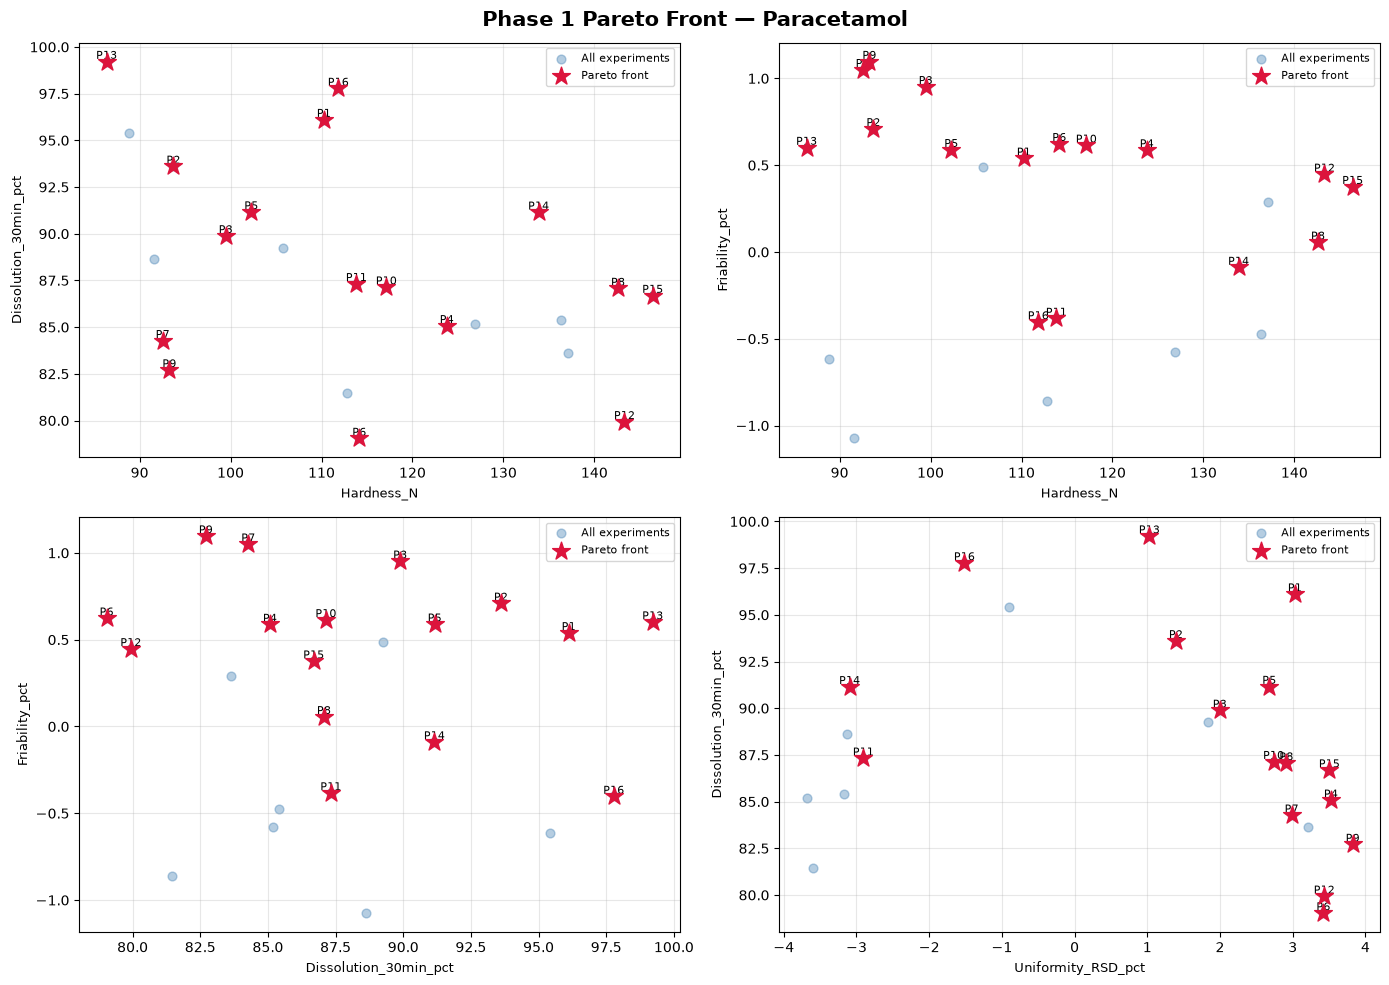

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Phase 1 Pareto Front — {alpha["api_name"]}', fontsize=15, fontweight='bold')

pairs = [
    ('Hardness_N', 'Dissolution_30min_pct'),
    ('Hardness_N', 'Friability_pct'),
    ('Dissolution_30min_pct', 'Friability_pct'),
    ('Uniformity_RSD_pct', 'Dissolution_30min_pct'),
]
for ax, (c1, c2) in zip(axes.flat, pairs):
    if c1 in cqa_names and c2 in cqa_names:
        i1, i2 = cqa_names.index(c1), cqa_names.index(c2)
        ax.scatter(Y_final[:, i1], Y_final[:, i2],
                   alpha=0.4, s=40, color='steelblue', label='All experiments')
        ax.scatter(pareto_Y[:, i1], pareto_Y[:, i2],
                   s=180, color='crimson', marker='*', zorder=5, label='Pareto front')
        # add uncertainty ellipses for Pareto points
        for s in range(len(pareto_X)):
            ax.annotate(f'P{s+1}', (pareto_Y[s, i1], pareto_Y[s, i2]),
                        fontsize=8, ha='center', va='bottom')
        ax.set_xlabel(c1, fontsize=9)
        ax.set_ylabel(c2, fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase1_pareto_front.png', dpi=150, bbox_inches='tight')
print('✓ Saved: phase1_pareto_front.png')
plt.show()

In [13]:
# FIX #13, #16, #18, #21: output includes uncertainty, sensitivity indices,
# PAR/BAR, metadata, and provenance. All required for Phase 2 handoff.

sensitivity = gp_final.sensitivity_indices()

# Proven Acceptable Range (PAR): mean ± 1.96σ for each CPP at Pareto solutions
par = {}
for j, name in enumerate(space['cpp_names']):
    vals = pareto_X[:, j]
    par[name] = {
        'mean'  : float(vals.mean()),
        'std'   : float(vals.std()),
        'ci95_lo': float(vals.mean() - 1.96 * vals.std()),
        'ci95_hi': float(vals.mean() + 1.96 * vals.std()),
        'unit'  : '%' if 'pct' in name.lower() else
                  '°C' if '_c' in name.lower() else
                  'kN' if 'kn' in name.lower() else
                  'rpm' if 'rpm' in name.lower() else
                  'kg' if 'kg' in name.lower() else 'dimensionless'
    }

pareto_records = []
for s in range(len(pareto_X)):
    rec = {
        'solution_id'  : s + 1,
        'cpps'         : {n: float(pareto_X[s, j]) for j, n in enumerate(space['cpp_names'])},
        'cqa_predicted': {}
    }
    for j, name in enumerate(cqa_names):
        rec['cqa_predicted'][name] = {
            'mean'   : float(pareto_means[s, j]),
            'std'    : float(pareto_stds[s, j]),
            'ci95_lo': float(pareto_ci_lo[s, j]),
            'ci95_hi': float(pareto_ci_hi[s, j]),
            'in_spec': bool(
                cqa_obj[name]['min'] <= pareto_means[s,j] <= cqa_obj[name]['max']
                if cqa_obj[name]['higher_is_better']
                else pareto_means[s,j] <= cqa_obj[name]['max']
            )
        }
    pareto_records.append(rec)

output = {
    # ── provenance & metadata ────────────────────────────────────────────
    'schema_version'  : '1.0',
    'timestamp'       : datetime.now().isoformat(),
    'random_seed'     : SEED,
    'api_name'        : alpha['api_name'],
    'bcs_class'       : alpha['bcs_class'],
    'primary_technique': beta['primary_technique'],
    'technique_confidence': beta['technique_confidence'],

    # ── experiment summary ───────────────────────────────────────────────
    'n_seed_experiments': int(n_seeds),
    'n_total_experiments': int(len(X_final)),
    'n_pareto_solutions' : int(len(pareto_X)),
    'loo_cv_r2'         : float(loo_r2_final),

    # ── main outputs for Phase 2 ─────────────────────────────────────────
    'pareto_solutions'         : pareto_records,     # Pareto CPPs + CQA predictions + CI
    'proven_acceptable_ranges' : par,                 # PAR/BAR for each CPP
    'sensitivity_indices'      : sensitivity,         # GP length-scale importance per CQA
    'cpp_bounds_used'          : {k: list(v) for k, v in space['bounds'].items()},

    # ── EHVI convergence trace ───────────────────────────────────────────
    'ehvi_history': ehvi_hist,
}

out_path = 'phase1_output.json'
with open(out_path, 'w') as f:
    json.dump(output, f, indent=2, default=str)

print(f'✓ Saved: {out_path}')
print(f"\n{'='*50}")
print('PHASE 1 COMPLETE')
print(f"  API              : {output['api_name']}")
print(f"  Total experiments: {output['n_total_experiments']}")
print(f"  Pareto solutions : {output['n_pareto_solutions']}")
print(f"  LOO-CV R²        : {output['loo_cv_r2']:.4f}")
print(f"  Output           : {out_path} → ready for Phase 2")
print(f"{'='*50}")

✓ Saved: phase1_output.json

PHASE 1 COMPLETE
  API              : Paracetamol
  Total experiments: 23
  Pareto solutions : 16
  LOO-CV R²        : -0.1686
  Output           : phase1_output.json → ready for Phase 2
